# Laboratorio 1: Análisis exploratorio de datos con Pandas y NumPy

**Andrés Felipe Serrano Barrios**

Física Computacional I (0302151), grupo 001

Instituto de Física, Universidad de Antioquia

Semestre 2026-2, profesor Andrés Felipe Rivera Romero

## Datos

El conjunto de datos es *Palmer Penguins*: características morfológicas y geográficas de tres
especies de pingüinos del archipiélago Palmer, en la Antártida. Las columnas son

```
[especie, isla, longitud del pico, profundidad del pico, longitud de la aleta, masa corporal, genero]
```

Se carga con `seaborn` y se descartan las filas incompletas con `dropna()`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

data = sns.load_dataset("penguins").dropna().values
df = pd.DataFrame(data, columns=["especie", "isla", "longitud_pico (mm)", "profundidad_pico (mm)", "longitud_aleta (mm)", "masa_corporal (g)", "genero"])

df[:5]

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


### Un detalle previo: los tipos de dato

El enunciado construye el `DataFrame` a partir de `.values`, que colapsa la tabla original a un
arreglo de NumPy. Como la tabla mezcla texto y números, ese arreglo queda de tipo `object` y las
cuatro columnas numéricas heredan ese tipo.

In [2]:
df.dtypes

especie                  object
isla                     object
longitud_pico (mm)       object
profundidad_pico (mm)    object
longitud_aleta (mm)      object
masa_corporal (g)        object
genero                   object
dtype: object

Con `dtype=object` las operaciones estadísticas o bien fallan o bien recorren la columna elemento
por elemento en Python puro, que es órdenes de magnitud más lento que una operación vectorizada.
Antes de calcular nada se convierten las cuatro columnas numéricas a punto flotante.

In [3]:
numeric_columns = ["longitud_pico (mm)", "profundidad_pico (mm)", "longitud_aleta (mm)", "masa_corporal (g)"]
df[numeric_columns] = df[numeric_columns].astype(float)

df.dtypes

especie                   object
isla                      object
longitud_pico (mm)       float64
profundidad_pico (mm)    float64
longitud_aleta (mm)      float64
masa_corporal (g)        float64
genero                    object
dtype: object

In [4]:
df.describe()

,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g)
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


Quedan **333 pingüinos** tras descartar los registros incompletos.

---

## 1. Profundidades del pico máxima y mínima en la isla Torgersen

Se filtran las filas cuya columna `isla` vale `Torgersen` y se resume la columna de profundidad del
pico con `agg()`.

In [5]:
torgersen_depth = df.loc[df["isla"] == "Torgersen", "profundidad_pico (mm)"]

torgersen_depth.agg(["count", "min", "max"])

count    47.0
min      15.9
max      21.5
Name: profundidad_pico (mm), dtype: float64

**Respuesta.** Entre los 47 pingüinos de la isla Torgersen, la profundidad del pico va de un
**mínimo de 15.9 mm** a un **máximo de 21.5 mm**.

Conviene notar que en Torgersen solo habita una especie, *Adelie*, así que ese rango de 5.6 mm es
dispersión dentro de una misma especie y no una diferencia entre especies.

In [6]:
df.loc[df["isla"] == "Torgersen", "especie"].unique()

array(['Adelie'], dtype=object)

BIEN...

---

## 2. Isla, especie y género del pingüino de mayor masa corporal

El enunciado pide usar `argmax()`. Esta función devuelve una posición dentro del arreglo, no una
etiqueta del índice, así que la fila se recupera con `iloc` y no con `loc`.

In [7]:
body_mass = df["masa_corporal (g)"].to_numpy()
heaviest_position = np.argmax(body_mass)

df.iloc[heaviest_position][["especie", "isla", "genero", "masa_corporal (g)"]]

especie              Gentoo
isla                 Biscoe
genero                 Male
masa_corporal (g)    6300.0
Name: 231, dtype: object

**Respuesta.** El pingüino más pesado del conjunto de datos es un **macho de la especie Gentoo, de
la isla Biscoe**, con una masa corporal de **6300 g**.

`argmax()` devuelve solo la primera coincidencia, de modo que si hubiera empates quedarían
ocultos. Se verifica que el máximo es único.

In [8]:
(df["masa_corporal (g)"] == df["masa_corporal (g)"].max()).sum()

1

Hay un único registro con esa masa, así que la respuesta no es ambigua.

---

## 3. Masa corporal media de los machos que no son de la especie Gentoo

Se combinan las dos condiciones con el operador `&`, que en pandas opera elemento a elemento sobre
las máscaras booleanas.

In [9]:
non_gentoo_males = df[(df["genero"] == "Male") & (df["especie"] != "Gentoo")]

non_gentoo_males["masa_corporal (g)"].mean()

4010.2803738317757

**Respuesta.** La masa corporal media de los pingüinos macho que no son Gentoo es de
**4010.3 g**, promediada sobre 107 individuos.

Ese promedio agrupa dos especies distintas, así que vale la pena separarlas.

BIEN


In [10]:
non_gentoo_males.groupby("especie")["masa_corporal (g)"].agg(["count", "mean", "std"]).round(2)

,count,mean,std
especie,,,
Adelie,73,4043.49,346.81
Chinstrap,34,3938.97,362.14


Los machos *Adelie* pesan en promedio 4043.5 g y los *Chinstrap* 3939.0 g. La diferencia entre
ambas medias, unos 105 g, es pequeña frente a la desviación estándar de cada grupo, cercana a
350 g: las dos especies son prácticamente indistinguibles por masa, y el contraste real está con
los Gentoo, que promedian 5092.4 g y son los que quedaron excluidos del filtro.

---

## 4. Distribución de la longitud del pico

Se usa `hist()` y se reportan la media y la desviación estándar en el título de la figura. Se toma
la desviación muestral, con `ddof = 1`, que es la que pandas usa por defecto; NumPy usa
`ddof = 0` y en este caso la diferencia es de apenas 0.01 mm.

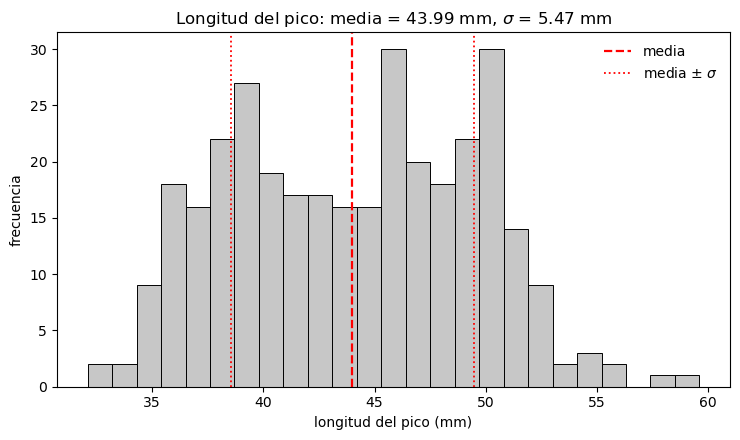

In [11]:
bill_length = df["longitud_pico (mm)"]
mean_length = bill_length.mean()
std_length = bill_length.std()

figure, axes = plt.subplots(figsize=(7.5, 4.5))
axes.hist(bill_length, bins=25, color="0.78", edgecolor="black", linewidth=0.7)
axes.axvline(mean_length, color="red", linestyle="--", linewidth=1.6, label="media")
axes.axvline(mean_length - std_length, color="red", linestyle=":", linewidth=1.3, label="media $\pm\ \sigma$")
axes.axvline(mean_length + std_length, color="red", linestyle=":", linewidth=1.3)
axes.set_xlabel("longitud del pico (mm)")
axes.set_ylabel("frecuencia")
axes.set_title(f"Longitud del pico: media = {mean_length:.2f} mm, $\sigma$ = {std_length:.2f} mm")
axes.legend(frameon=False)

plt.tight_layout()
plt.show()

**Respuesta.** La longitud del pico tiene una **media de 43.99 mm** y una **desviación estándar de
5.47 mm**.

El histograma no es una campana: se ven dos cúmulos separados, uno alrededor de 39 mm y otro
alrededor de 47 mm. Esa estructura bimodal significa que la media y la desviación estándar no
describen bien la muestra, porque resumen con dos números una distribución que es en realidad la
superposición de poblaciones distintas. Separando por especie se ve de dónde sale cada cúmulo.

In [12]:
df.groupby("especie")["longitud_pico (mm)"].agg(["count", "mean", "std"]).round(2)

,count,mean,std
especie,,,
Adelie,146,38.82,2.66
Chinstrap,68,48.83,3.34
Gentoo,119,47.57,3.11


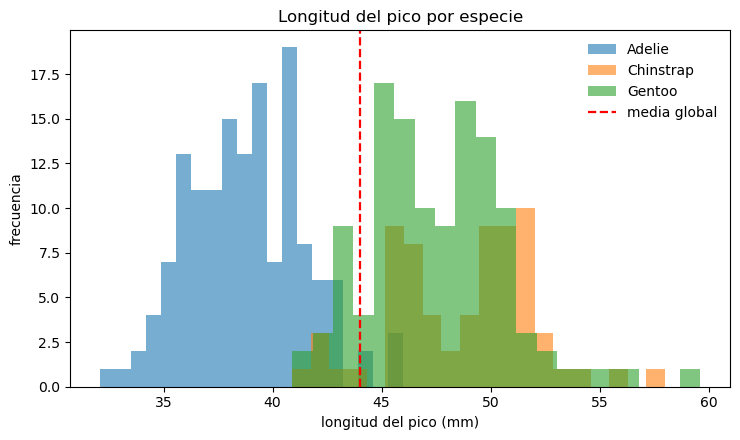

In [13]:
figure, axes = plt.subplots(figsize=(7.5, 4.5))
for species_name in ["Adelie", "Chinstrap", "Gentoo"]:
    axes.hist(df.loc[df["especie"] == species_name, "longitud_pico (mm)"], bins=20, alpha=0.6, label=species_name)
axes.axvline(mean_length, color="red", linestyle="--", linewidth=1.6, label="media global")
axes.set_xlabel("longitud del pico (mm)")
axes.set_ylabel("frecuencia")
axes.set_title("Longitud del pico por especie")
axes.legend(frameon=False)

plt.tight_layout()
plt.show()

MUY BIEN..

El cúmulo de la izquierda son los *Adelie*, con 38.82 mm de media, y el de la derecha lo forman
*Chinstrap* y *Gentoo*, con 48.83 mm y 47.57 mm, que se solapan casi por completo. La media global
de 43.99 mm cae en el valle entre ambos grupos y no corresponde a ningún pingüino típico.

---

## 5. Islas y especies presentes, sus frecuencias y la distribución de masa corporal

`value_counts()` da la frecuencia de cada categoría.

In [14]:
df["isla"].value_counts()

Biscoe       163
Dream        123
Torgersen     47
Name: isla, dtype: int64

In [15]:
df["especie"].value_counts()

Adelie       146
Gentoo       119
Chinstrap     68
Name: especie, dtype: int64

**Respuesta.** El conjunto de datos tiene **tres islas**, Biscoe con 163 pingüinos, Dream con 123 y
Torgersen con 47, y **tres especies**, *Adelie* con 146, *Gentoo* con 119 y *Chinstrap* con 68.

Las dos categorías no son independientes. La tabla cruzada muestra que cada especie ocupa un
subconjunto muy definido de islas.

In [16]:
pd.crosstab(df["isla"], df["especie"], margins=True, margins_name="total")

especie,Adelie,Chinstrap,Gentoo,total
isla,,,,
Biscoe,44,0,119,163
Dream,55,68,0,123
Torgersen,47,0,0,47
total,146,68,119,333


Solo los *Adelie* aparecen en las tres islas. Los *Gentoo* viven únicamente en Biscoe y los
*Chinstrap* únicamente en Dream, y Torgersen es exclusivamente de *Adelie*. Este es el motivo por
el que en el punto 1 el rango de Torgersen correspondía a una sola especie.

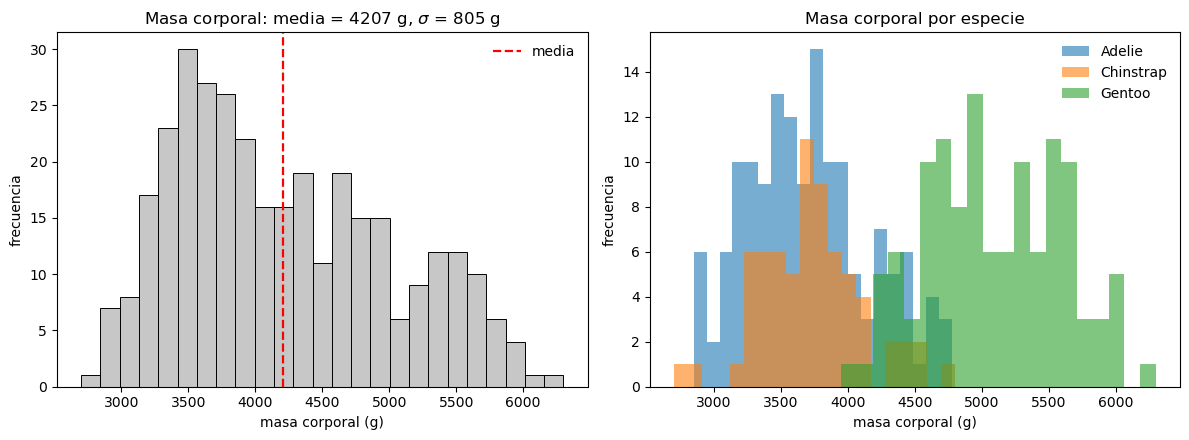

In [17]:
body_mass_series = df["masa_corporal (g)"]

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(body_mass_series, bins=25, color="0.78", edgecolor="black", linewidth=0.7)
axes[0].axvline(body_mass_series.mean(), color="red", linestyle="--", linewidth=1.6, label="media")
axes[0].set_xlabel("masa corporal (g)")
axes[0].set_ylabel("frecuencia")
axes[0].set_title(f"Masa corporal: media = {body_mass_series.mean():.0f} g, $\sigma$ = {body_mass_series.std():.0f} g")
axes[0].legend(frameon=False)

for species_name in ["Adelie", "Chinstrap", "Gentoo"]:
    axes[1].hist(df.loc[df["especie"] == species_name, "masa_corporal (g)"], bins=20, alpha=0.6, label=species_name)
axes[1].set_xlabel("masa corporal (g)")
axes[1].set_ylabel("frecuencia")
axes[1].set_title("Masa corporal por especie")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

La masa corporal va de 2700 g a 6300 g, con media 4207 g y desviación estándar 805 g, y vuelve a
presentar dos modos. El panel derecho muestra el origen: *Adelie* y *Chinstrap* se superponen
alrededor de 3700 g mientras que los *Gentoo* forman un grupo aparte cerca de 5100 g, unos 1400 g
por encima.

Se repite entonces el patrón del punto 4. En este conjunto de datos la variable que organiza la
morfología es la especie, y cualquier estadístico calculado sobre el total mezcla poblaciones que
conviene tratar por separado.

In [18]:
df.groupby("especie")["masa_corporal (g)"].agg(["count", "mean", "std", "min", "max"]).round(2)

,count,mean,std,min,max
especie,,,,,
Adelie,146,3706.16,458.62,2850.0,4775.0
Chinstrap,68,3733.09,384.34,2700.0,4800.0
Gentoo,119,5092.44,501.48,3950.0,6300.0


---

## Resumen de respuestas

| # | Pregunta | Respuesta |
|---|---|---|
| 1 | Profundidad del pico máxima y mínima en Torgersen | 21.5 mm y 15.9 mm, sobre 47 pingüinos |
| 2 | Pingüino de mayor masa corporal | Gentoo, macho, isla Biscoe, 6300 g |
| 3 | Masa media de los machos que no son Gentoo | 4010.3 g, sobre 107 individuos |
| 4 | Longitud del pico | media 43.99 mm, desviación estándar 5.47 mm, distribución bimodal |
| 5 | Islas y especies | Biscoe 163, Dream 123, Torgersen 47; Adelie 146, Gentoo 119, Chinstrap 68 |

MUY BIEN NOTA 5.0